# Wstęp do Sztucznej Inteligencji

Przed rozpoczęciem pracy z notatnikiem zmień jego nazwę zgodnie z wzorem: `NrAlbumu_Nazwisko_Imie_PoprzedniaNazwa`.

Przed wysłaniem notatnika upewnij się, że rozwiązałeś wszystkie zadania/ćwiczenia.

# Temat:  Wnioskowanie oparte na wiedzy niepewnej. Wnioskowanie rozmyte
Zapoznaj się z treścią niniejszego notatnika czytając i wykonując go komórka po komórce. Wykonaj napotkane zadania/ćwiczenia.

Na niniejszych laboratoriach będziemy wykorzystywać bibliotekę `fuzzython`(https://github.com/yudivian/fuzzython). Orginalny moduł zawierał kilka błędów przez co nie dało się go zainstalować za pomocą `pip`. Aby móc z niego zkorzystać należy pobrać zmodyfikowany moduł `fuzzython.zip` (plik dostępny na delcie), rozpakować go i wrzucić na dysk google, a następnie wykonać poniższą komórkę montującą dysk google:


In [ ]:
import sys
from pathlib import Path

# Colab-specific setup is optional. In a local notebook, just skip it.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    path_nb = r'/content/drive/My Drive/Colab Notebooks/WdSI_2023/T4_Fuzzy'
    sys.path.append(path_nb)
except Exception:
    # Local environment fallback
    path_nb = str(Path.cwd())


Przy importowaniu elementów z modułu `fuzzython` używamy konstrukcji:
```python
from fuzzython.nazwa_podmodulu import jakies, funkcje, klasy, itp.
```

## Zadanie 1 (obowiązkowe, 5pkt)
Zaprojektuj system rozmyty typu Mamdani, który będzie oceniał stopień przekonania o możliwości spowodowania wypadku podczas jazdy samochodem.

Zmienne wejściowe: 

- prędkość jazdy (10 − 200km/h ): `mała`, `średnia`, `szybka`, `bardzo szybka` 
- widoczność (0.05 − 4km): `bardzo słaba`, `średnia`, `dobra`. 

Wyjście systemu: 

- stopień przekonania o możliwości spowodowania wypadku (0 − 1): `bardzo małe`, `małe`, `średnie`, `duże`.

Zdefiniuj własne kształty dla zbiorów rozmytych, stwórz własne reguły oraz przygotuj wykresy ilustrujące funkcje przynależności zbiorów rozmytych jak również powierzchnię decyzyjną sterownika rozmytego.

### TWÓJ PROGRAM:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Generic fuzzy utilities
# -------------------------
def triangular(x, a, b, c):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    left = (a < x) & (x < b)
    right = (b <= x) & (x < c)
    if b != a:
        y[left] = (x[left] - a) / (b - a)
    if c != b:
        y[right] = (c - x[right]) / (c - b)
    y[x == b] = 1.0
    return np.clip(y, 0.0, 1.0)

def trapezoidal(x, a, b, c, d):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x)
    rise = (a < x) & (x < b)
    top = (b <= x) & (x <= c)
    fall = (c < x) & (x < d)
    if b != a:
        y[rise] = (x[rise] - a) / (b - a)
    y[top] = 1.0
    if d != c:
        y[fall] = (d - x[fall]) / (d - c)
    return np.clip(y, 0.0, 1.0)

def centroid(x, mu):
    area = np.trapezoid(mu, x)
    if area == 0:
        return float("nan")
    return float(np.trapezoid(x * mu, x) / area)

def mf_value(func, value):
    return float(func(np.array([value]))[0])

def plot_memberships(x, mfs, title, xlabel):
    plt.figure(figsize=(9, 4.5))
    for name, mf in mfs.items():
        plt.plot(x, mf, label=name, linewidth=2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Membership")
    plt.ylim(-0.02, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------
# Task 1: Mamdani system
# -------------------------
speed_x = np.linspace(10, 200, 600)
vis_x = np.linspace(0.05, 4.0, 600)
risk_x = np.linspace(0.0, 1.0, 800)

speed_mfs = {
    "mała": trapezoidal(speed_x, 10, 10, 35, 70),
    "średnia": triangular(speed_x, 50, 95, 140),
    "szybka": triangular(speed_x, 115, 150, 185),
    "bardzo szybka": trapezoidal(speed_x, 165, 185, 200, 200),
}

vis_mfs = {
    "bardzo słaba": trapezoidal(vis_x, 0.05, 0.05, 0.35, 1.0),
    "średnia": triangular(vis_x, 0.7, 1.8, 3.0),
    "dobra": trapezoidal(vis_x, 2.2, 3.0, 4.0, 4.0),
}

risk_mfs = {
    "bardzo małe": trapezoidal(risk_x, 0.0, 0.0, 0.12, 0.28),
    "małe": triangular(risk_x, 0.18, 0.34, 0.50),
    "średnie": triangular(risk_x, 0.42, 0.60, 0.78),
    "duże": trapezoidal(risk_x, 0.68, 0.84, 1.0, 1.0),
}

plot_memberships(speed_x, speed_mfs, "Prędkość jazdy", "km/h")
plot_memberships(vis_x, vis_mfs, "Widoczność", "km")
plot_memberships(risk_x, risk_mfs, "Stopień przekonania o wypadku", "0..1")

def mamdani_accident_risk(speed, visibility):
    mu_speed = {
        "mała": mf_value(lambda x: trapezoidal(x, 10, 10, 35, 70), speed),
        "średnia": mf_value(lambda x: triangular(x, 50, 95, 140), speed),
        "szybka": mf_value(lambda x: triangular(x, 115, 150, 185), speed),
        "bardzo szybka": mf_value(lambda x: trapezoidal(x, 165, 185, 200, 200), speed),
    }
    mu_vis = {
        "bardzo słaba": mf_value(lambda x: trapezoidal(x, 0.05, 0.05, 0.35, 1.0), visibility),
        "średnia": mf_value(lambda x: triangular(x, 0.7, 1.8, 3.0), visibility),
        "dobra": mf_value(lambda x: trapezoidal(x, 2.2, 3.0, 4.0, 4.0), visibility),
    }

    rules = [
        ("duże", min(mu_speed["bardzo szybka"], mu_vis["bardzo słaba"])),
        ("duże", min(mu_speed["bardzo szybka"], mu_vis["średnia"])),
        ("duże", min(mu_speed["bardzo szybka"], mu_vis["dobra"])),
        ("duże", min(mu_speed["szybka"], mu_vis["bardzo słaba"])),
        ("duże", min(mu_speed["szybka"], mu_vis["średnia"])),
        ("średnie", min(mu_speed["szybka"], mu_vis["dobra"])),
        ("duże", min(mu_speed["średnia"], mu_vis["bardzo słaba"])),
        ("średnie", min(mu_speed["średnia"], mu_vis["średnia"])),
        ("małe", min(mu_speed["średnia"], mu_vis["dobra"])),
        ("średnie", min(mu_speed["mała"], mu_vis["bardzo słaba"])),
        ("małe", min(mu_speed["mała"], mu_vis["średnia"])),
        ("bardzo małe", min(mu_speed["mała"], mu_vis["dobra"])),
    ]

    aggregated = np.zeros_like(risk_x)
    for label, strength in rules:
        if strength <= 0:
            continue
        aggregated = np.maximum(aggregated, np.minimum(risk_mfs[label], strength))

    crisp = centroid(risk_x, aggregated)
    return crisp, aggregated, mu_speed, mu_vis, rules

example_speed = 140
example_visibility = 0.9
crisp_risk, agg_risk, mu_speed_example, mu_vis_example, rules_used = mamdani_accident_risk(
    example_speed, example_visibility
)
print("Mamdani example:")
print(f"  speed={example_speed} km/h, visibility={example_visibility} km")
print(f"  crisp risk = {crisp_risk:.4f}")

speed_grid = np.linspace(10, 200, 70)
vis_grid = np.linspace(0.05, 4.0, 70)
Z = np.zeros((len(vis_grid), len(speed_grid)))

for i, v in enumerate(vis_grid):
    for j, s in enumerate(speed_grid):
        z, _, _, _, _ = mamdani_accident_risk(s, v)
        Z[i, j] = z

S, V = np.meshgrid(speed_grid, vis_grid)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(S, V, Z, cmap="viridis", edgecolor="none")
ax.set_title("Powierzchnia decyzyjna - system Mamdaniego")
ax.set_xlabel("Prędkość [km/h]")
ax.set_ylabel("Widoczność [km]")
ax.set_zlabel("Ryzyko wypadku")
fig.colorbar(surf, ax=ax, shrink=0.6, label="Ryzyko")
plt.tight_layout()
plt.show()


/home/user/intro-to-ai/5/fuzzython/fsets/triangular.py:13: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  _/   |   \_
/home/user/intro-to-ai/5/fuzzython/fsets/triangular.py:70: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  _/   |   \_  y_min=0
/home/user/intro-to-ai/5/fuzzython/fsets/triangular.py:13: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  _/   |   \_
/home/user/intro-to-ai/5/fuzzython/fsets/triangular.py:70: SyntaxWarning: "\_" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\_"? A raw string is also an option.
  _/   |   \_  y_min=0


ZeroDivisionError: division by zero

## Zadanie 2 (obowiązkowe, 5pkt)
Zaprojektuj system rozmyty typu Takagi-Sugeno, który będzie prognozował cenę akcji na jeden dzień do przodu.

Zmienne wejściowe: 

- cena akcji wczoraj (1 − 20zł): `niska`, `średnia`, `wysoka`, 

- cena akcji dziś (1 − 20zł): `niska`, `średnia`, `wysoka`. 

Wyjście systemu: 

- cena akcji jutro dana równaniem regresji: $\alpha\cdot x + \beta\cdot y + \gamma$

Reguły postaci:

- Jeśli cena akcji wczoraj była $A_i$ i cena akcji dziś jest $B_i$ to cena akcji jutro będzie $\alpha_k\cdot x + \beta_k\cdot y + \gamma_k$,

gdzie:

- $x$ to cena akcji wczoraj (ostra wartość)

- $y$ to cena akcji dziś (ostra wartość)

- $A_i, B_i$ to zbiory rozmyte odpowiednio dla ceny akcji wczoraj i dziś

- $\alpha_k, \beta_k, \gamma_k$ - współczynniki w równaniu regresji (liczby rzeczywiste)

- $k$ - numer reguły

Zdefiniuj własne kształty dla zbiorów rozmytych, stwórz własne reguły (dobór współczynników regresji) oraz przygotuj wykresy ilustrujące funkcje przynależności zbiorów rozmytych jak również powierzchnię decyzyjną sterownika rozmytego.

### TWÓJ PROGRAM:

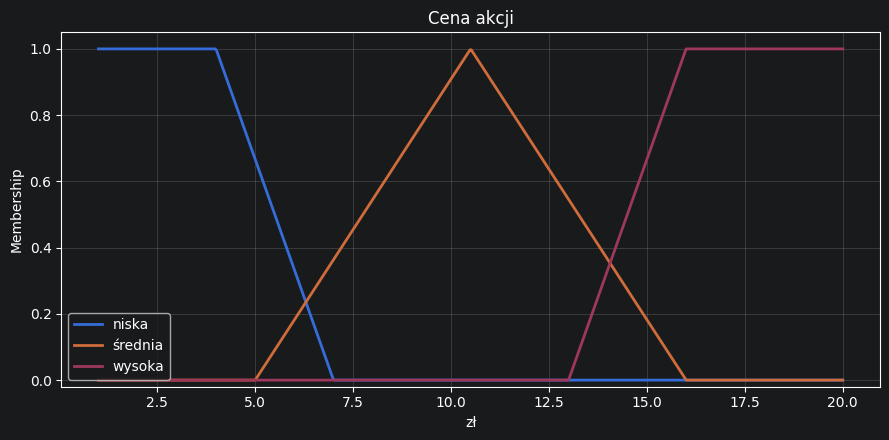


Sugeno example:
  yesterday=8 zł, today=14 zł
  predicted tomorrow = 10.8739 zł


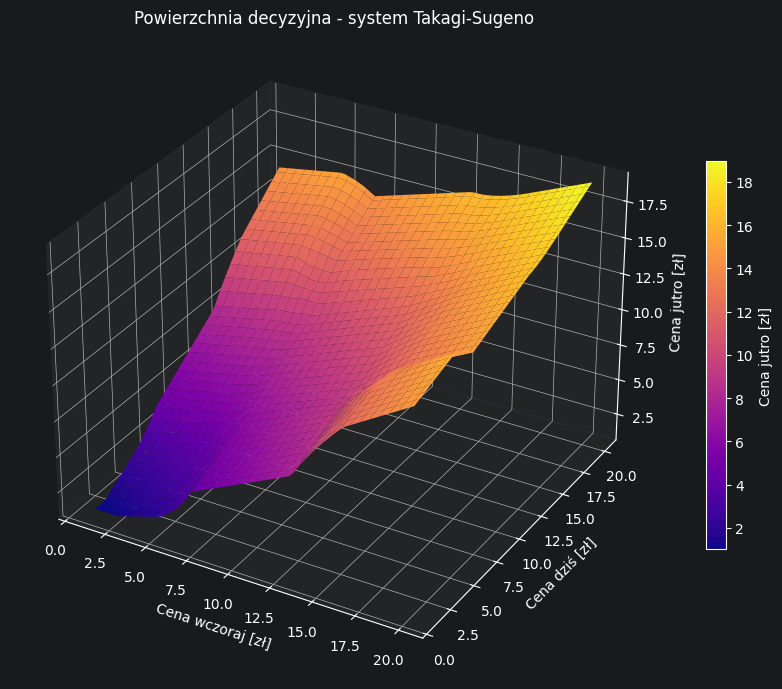

In [2]:
# -------------------------
# Task 2: Takagi-Sugeno system
# -------------------------
stock_x = np.linspace(1, 20, 600)

stock_mfs = {
    "niska": trapezoidal(stock_x, 1, 1, 4, 7),
    "średnia": triangular(stock_x, 5, 10.5, 16),
    "wysoka": trapezoidal(stock_x, 13, 16, 20, 20),
}

plot_memberships(stock_x, stock_mfs, "Cena akcji", "zł")

def stock_memberships(value):
    return {
        "niska": mf_value(lambda x: trapezoidal(x, 1, 1, 4, 7), value),
        "średnia": mf_value(lambda x: triangular(x, 5, 10.5, 16), value),
        "wysoka": mf_value(lambda x: trapezoidal(x, 13, 16, 20, 20), value),
    }

def sugeno_next_price(yesterday, today):
    mu_y = stock_memberships(yesterday)
    mu_t = stock_memberships(today)

    rules = [
        (min(mu_y["niska"], mu_t["niska"]),  lambda x, y: 0.55*x + 0.35*y - 0.4),
        (min(mu_y["niska"], mu_t["średnia"]), lambda x, y: 0.35*x + 0.55*y + 0.2),
        (min(mu_y["niska"], mu_t["wysoka"]),  lambda x, y: 0.25*x + 0.70*y + 0.6),

        (min(mu_y["średnia"], mu_t["niska"]),  lambda x, y: 0.60*x + 0.25*y + 0.1),
        (min(mu_y["średnia"], mu_t["średnia"]),lambda x, y: 0.45*x + 0.45*y + 0.4),
        (min(mu_y["średnia"], mu_t["wysoka"]),  lambda x, y: 0.30*x + 0.60*y + 0.7),

        (min(mu_y["wysoka"], mu_t["niska"]),   lambda x, y: 0.70*x + 0.20*y + 0.3),
        (min(mu_y["wysoka"], mu_t["średnia"]),  lambda x, y: 0.55*x + 0.35*y + 0.8),
        (min(mu_y["wysoka"], mu_t["wysoka"]),   lambda x, y: 0.40*x + 0.50*y + 1.1),
    ]

    weights = np.array([w for w, _ in rules], dtype=float)
    outputs = np.array([f(yesterday, today) for _, f in rules], dtype=float)
    total = weights.sum()
    crisp = float(np.dot(weights, outputs) / total) if total > 0 else float("nan")
    return float(np.clip(crisp, 1.0, 20.0)), weights, outputs, mu_y, mu_t

example_yesterday = 8
example_today = 14
next_price, weights, outputs, mu_y, mu_t = sugeno_next_price(example_yesterday, example_today)
print("\nSugeno example:")
print(f"  yesterday={example_yesterday} zł, today={example_today} zł")
print(f"  predicted tomorrow = {next_price:.4f} zł")

grid = np.linspace(1, 20, 70)
Z2 = np.zeros((len(grid), len(grid)))

for i, y in enumerate(grid):
    for j, t in enumerate(grid):
        z, _, _, _, _ = sugeno_next_price(y, t)
        Z2[i, j] = z

Y, T = np.meshgrid(grid, grid)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(Y, T, Z2, cmap="plasma", edgecolor="none")
ax.set_title("Powierzchnia decyzyjna - system Takagi-Sugeno")
ax.set_xlabel("Cena wczoraj [zł]")
ax.set_ylabel("Cena dziś [zł]")
ax.set_zlabel("Cena jutro [zł]")
fig.colorbar(surf, ax=ax, shrink=0.6, label="Cena jutro [zł]")
plt.tight_layout()
plt.show()


&copy; Cracow University of Technology